In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from attrition_analysis.models_utils import (
    estimators_dict,
    mixed_models_dict_c,
    categorical_models_dict_c,
    prepare_model_data,
    run_cross_validation_mixed,
    run_model_comparison_mixed,
)


df = pd.read_csv("../../data/clean/Employee-Attrition_Clean.csv")

target = "AttritionFlag"

logistic_estimators_dict = {
    "Logistic Regression": estimators_dict["Logistic Regression"],
    "Logistic Regression Balanced": estimators_dict["Logistic Regression Balanced"]
}

In [2]:
all_models_dict_c = {**categorical_models_dict_c, **mixed_models_dict_c}

In [3]:
general_comparison_lr, threshold_comparison_lr, confusion_results_lr, trained_models_lr, interpretation_results_lr = run_model_comparison_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict=logistic_estimators_dict,
    target=target
)


general_comparison_lr.sort_values(by=["F1-score", "AUC"], ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
28,Modelo 8 — Integrado Multidimensional,Logistic Regression,0.5,0.880,0.696,0.451,0.547,0.816,7,11,43
17,Modelo 2 — Nível Hierárquico e Benefícios,Logistic Regression Balanced,0.5,0.773,0.393,0.746,0.515,0.832,3,8,25
3,Modelo 2 — Nível Hierárquico,Logistic Regression Balanced,0.5,0.773,0.393,0.746,0.515,0.818,0,8,22
19,Modelo 3 — Rendimento Quantitativo,Logistic Regression Balanced,0.5,0.760,0.378,0.761,0.505,0.797,4,6,19
29,Modelo 8 — Integrado Multidimensional,Logistic Regression Balanced,0.5,0.778,0.392,0.690,0.500,0.813,7,11,43
23,Modelo 5 — Antiguidade Organizacional,Logistic Regression Balanced,0.5,0.766,0.379,0.704,0.493,0.782,5,6,20
21,Modelo 4 — Experiência Profissional,Logistic Regression Balanced,0.5,0.766,0.377,0.690,0.488,0.796,4,6,19
11,Modelo 6 — Perfil Pessoal,Logistic Regression Balanced,0.5,0.757,0.368,0.704,0.483,0.806,0,9,24
25,Modelo 6 — Perfil Pessoal e Condições de Trabalho,Logistic Regression Balanced,0.5,0.755,0.363,0.690,0.476,0.806,3,8,24
5,Modelo 3 — Faixa Salarial,Logistic Regression Balanced,0.5,0.746,0.353,0.690,0.467,0.795,0,8,21


In [4]:
best_thresholds_lr = threshold_comparison_lr.loc[
    threshold_comparison_lr.groupby(["Variable_Set", "Model"])["F1-score"].idxmax()
].reset_index(drop=True)

best_thresholds_lr.sort_values(by="F1-score", ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
28,Modelo 8 — Integrado Multidimensional,Logistic Regression,0.375,0.868,0.594,0.577,0.586,0.816
6,Modelo 2 — Nível Hierárquico e Benefícios,Logistic Regression,0.275,0.850,0.529,0.634,0.577,0.833
29,Modelo 8 — Integrado Multidimensional,Logistic Regression Balanced,0.625,0.844,0.511,0.648,0.571,0.813
9,Modelo 3 — Faixa Salarial,Logistic Regression Balanced,0.625,0.841,0.506,0.592,0.545,0.795
7,Modelo 2 — Nível Hierárquico e Benefícios,Logistic Regression Balanced,0.600,0.821,0.461,0.662,0.543,0.832
5,Modelo 2 — Nível Hierárquico,Logistic Regression Balanced,0.575,0.819,0.456,0.662,0.540,0.818
4,Modelo 2 — Nível Hierárquico,Logistic Regression,0.200,0.810,0.441,0.690,0.538,0.819
11,Modelo 3 — Rendimento Quantitativo,Logistic Regression Balanced,0.525,0.787,0.412,0.761,0.535,0.797
22,Modelo 6 — Perfil Pessoal e Condições de Trabalho,Logistic Regression,0.225,0.823,0.463,0.620,0.530,0.811
23,Modelo 6 — Perfil Pessoal e Condições de Trabalho,Logistic Regression Balanced,0.575,0.819,0.455,0.634,0.529,0.806


In [5]:
top_5_best_lr = best_thresholds_lr.sort_values(by="F1-score", ascending=False).head(5).reset_index(drop=True)

top_5_best_lr

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
0,Modelo 8 — Integrado Multidimensional,Logistic Regression,0.375,0.868,0.594,0.577,0.586,0.816
1,Modelo 2 — Nível Hierárquico e Benefícios,Logistic Regression,0.275,0.850,0.529,0.634,0.577,0.833
2,Modelo 8 — Integrado Multidimensional,Logistic Regression Balanced,0.625,0.844,0.511,0.648,0.571,0.813
3,Modelo 3 — Faixa Salarial,Logistic Regression Balanced,0.625,0.841,0.506,0.592,0.545,0.795
4,Modelo 2 — Nível Hierárquico e Benefícios,Logistic Regression Balanced,0.600,0.821,0.461,0.662,0.543,0.832


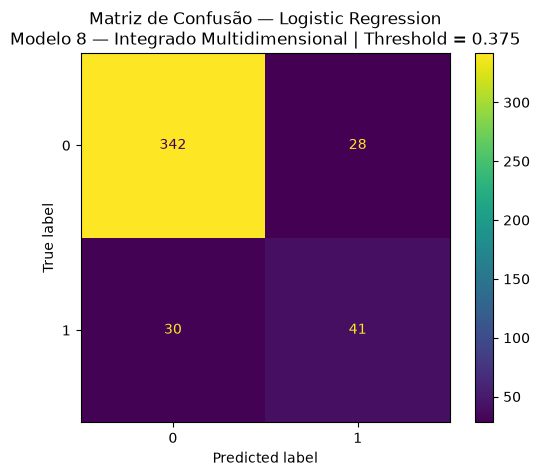

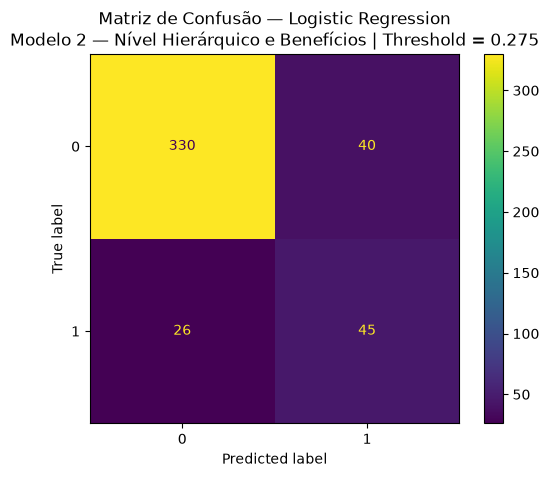

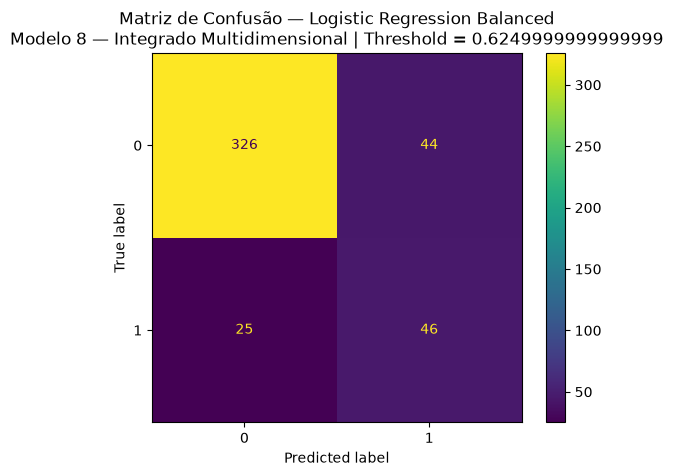

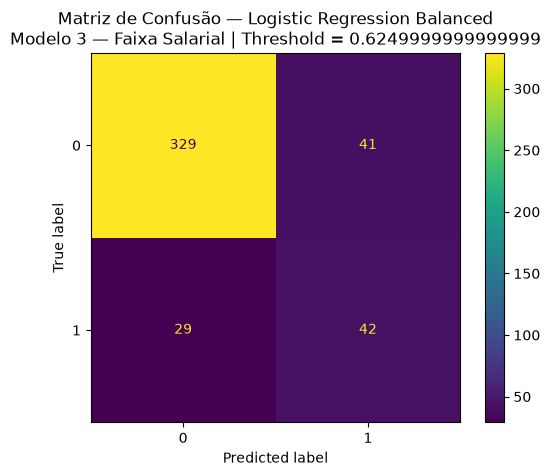

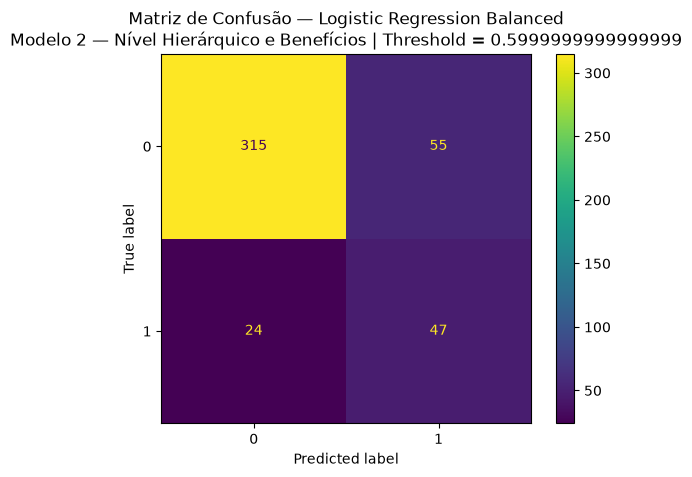

In [6]:
for _, row in top_5_best_lr.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    best_threshold = row["Threshold"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    X_train_model = X_train.copy()
    X_test_model = X_test.copy()
    
    if len(numeric_vars) > 0:
        
        numeric_cols_existing = [
            col for col in numeric_vars
            if col in X_train_model.columns
        ]
        
        scaler = StandardScaler()
        
        X_train_model[numeric_cols_existing] = scaler.fit_transform(
            X_train_model[numeric_cols_existing]
        )
        
        X_test_model[numeric_cols_existing] = scaler.transform(
            X_test_model[numeric_cols_existing]
        )
    
    estimator = clone(logistic_estimators_dict[model_name]["estimator"])
    
    estimator.fit(X_train_model, y_train)
    
    y_prob = estimator.predict_proba(X_test_model)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusão — {model_name}\n{variable_set_name} | Threshold = {best_threshold}")
    plt.show()

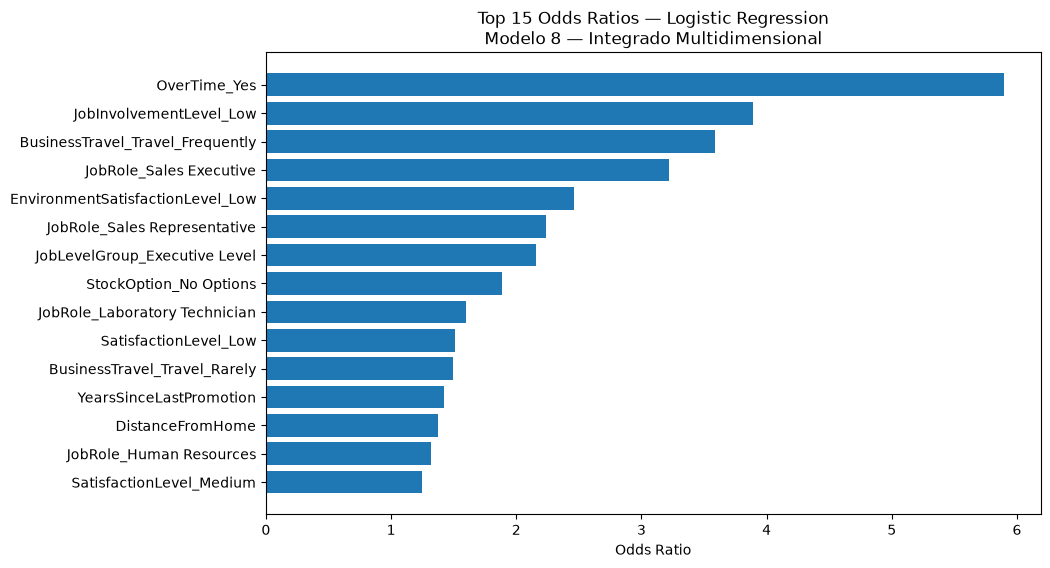

,Feature,Coefficient,Odds_Ratio
7,OverTime_Yes,1.774347,5.896432
31,JobInvolvementLevel_Low,1.358000,3.888408
29,BusinessTravel_Travel_Frequently,1.277564,3.587890
14,JobRole_Sales Executive,1.168682,3.217750
34,EnvironmentSatisfactionLevel_Low,0.901941,2.464382
15,JobRole_Sales Representative,0.803713,2.233820
16,JobLevelGroup_Executive Level,0.770591,2.161043
22,StockOption_No Options,0.634089,1.885304
9,JobRole_Laboratory Technician,0.471455,1.602323
37,SatisfactionLevel_Low,0.410362,1.507364


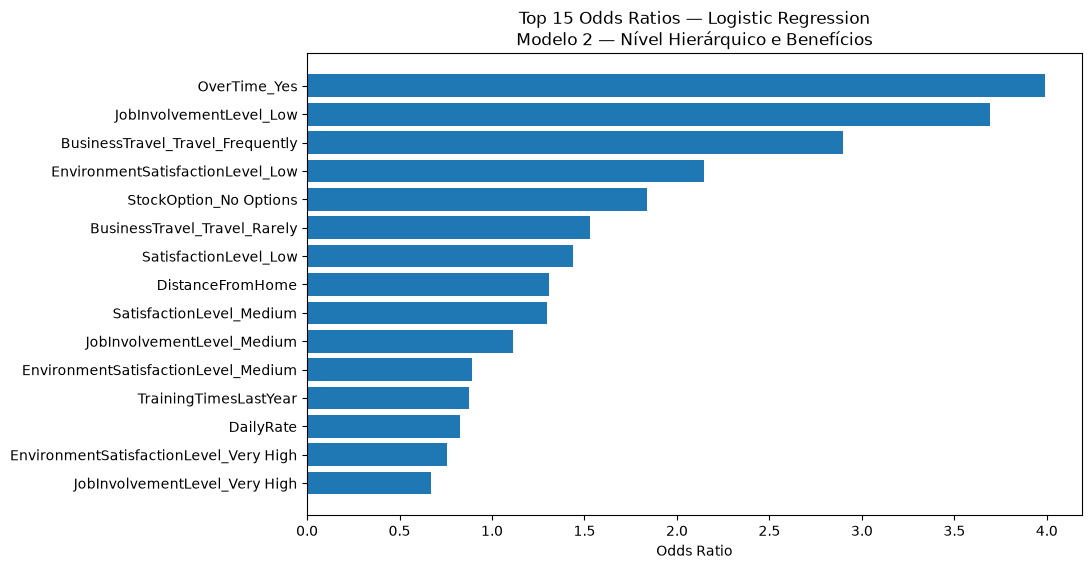

,Feature,Coefficient,Odds_Ratio
3,OverTime_Yes,1.384057,3.991062
13,JobInvolvementLevel_Low,1.305785,3.690586
11,BusinessTravel_Travel_Frequently,1.064328,2.898892
16,EnvironmentSatisfactionLevel_Low,0.763576,2.145936
10,StockOption_No Options,0.607871,1.836517
12,BusinessTravel_Travel_Rarely,0.426132,1.531323
19,SatisfactionLevel_Low,0.361816,1.435935
0,DistanceFromHome,0.269911,1.309848
20,SatisfactionLevel_Medium,0.259046,1.295694
14,JobInvolvementLevel_Medium,0.105592,1.111369


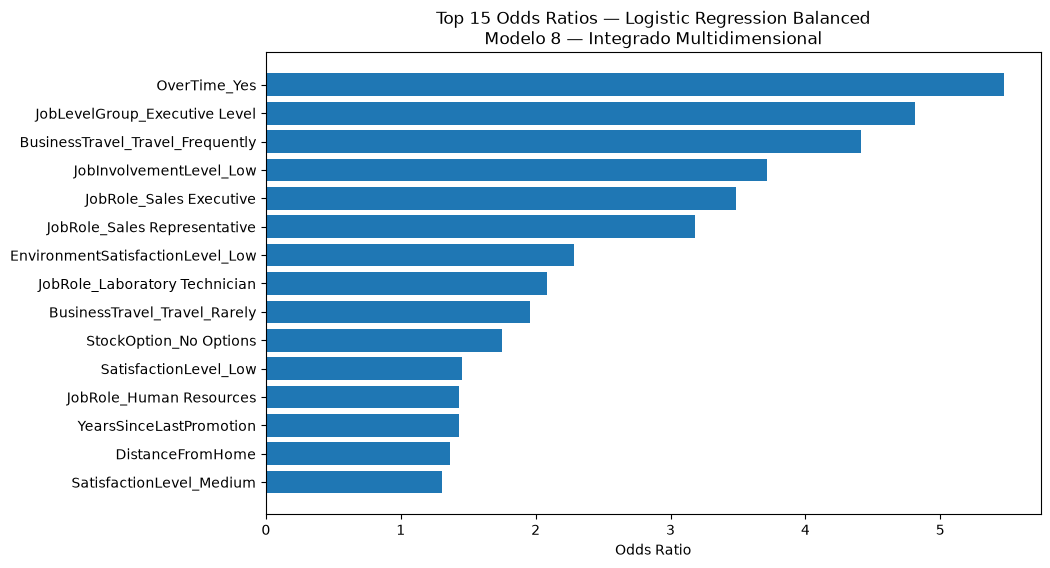

,Feature,Coefficient,Odds_Ratio
7,OverTime_Yes,1.699782,5.472751
16,JobLevelGroup_Executive Level,1.571794,4.815281
29,BusinessTravel_Travel_Frequently,1.483739,4.409402
31,JobInvolvementLevel_Low,1.311961,3.713450
14,JobRole_Sales Executive,1.248081,3.483650
15,JobRole_Sales Representative,1.157635,3.182398
34,EnvironmentSatisfactionLevel_Low,0.827068,2.286604
9,JobRole_Laboratory Technician,0.735733,2.087012
30,BusinessTravel_Travel_Rarely,0.673136,1.960375
22,StockOption_No Options,0.560367,1.751315


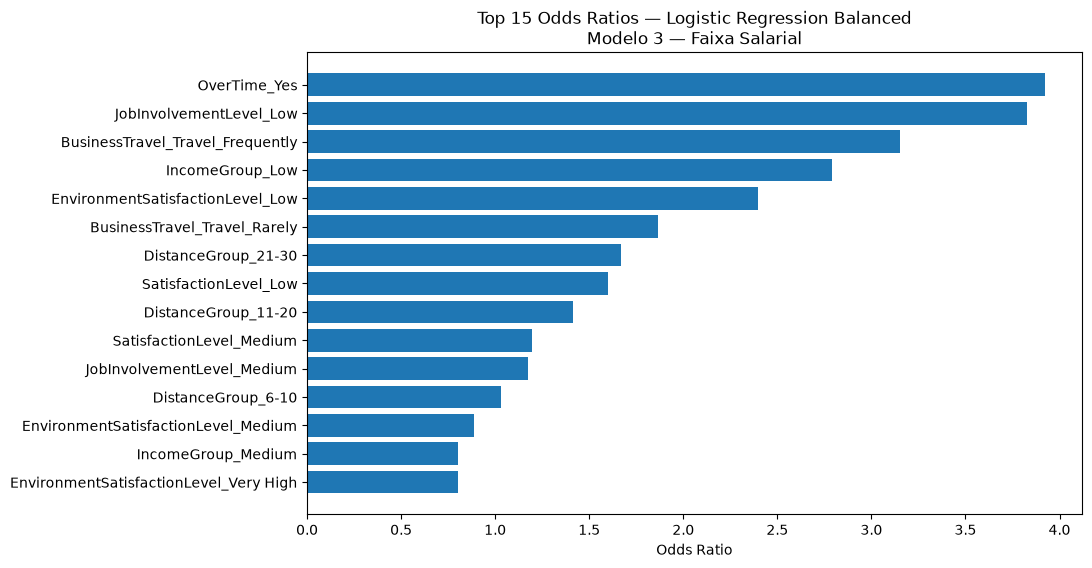

,Feature,Coefficient,Odds_Ratio
0,OverTime_Yes,1.367068,3.923829
6,JobInvolvementLevel_Low,1.342298,3.827830
4,BusinessTravel_Travel_Frequently,1.148546,3.153605
1,IncomeGroup_Low,1.025723,2.789110
9,EnvironmentSatisfactionLevel_Low,0.873338,2.394893
5,BusinessTravel_Travel_Rarely,0.624339,1.867011
19,DistanceGroup_21-30,0.511079,1.667089
12,SatisfactionLevel_Low,0.471160,1.601851
18,DistanceGroup_11-20,0.347909,1.416104
13,SatisfactionLevel_Medium,0.180842,1.198226


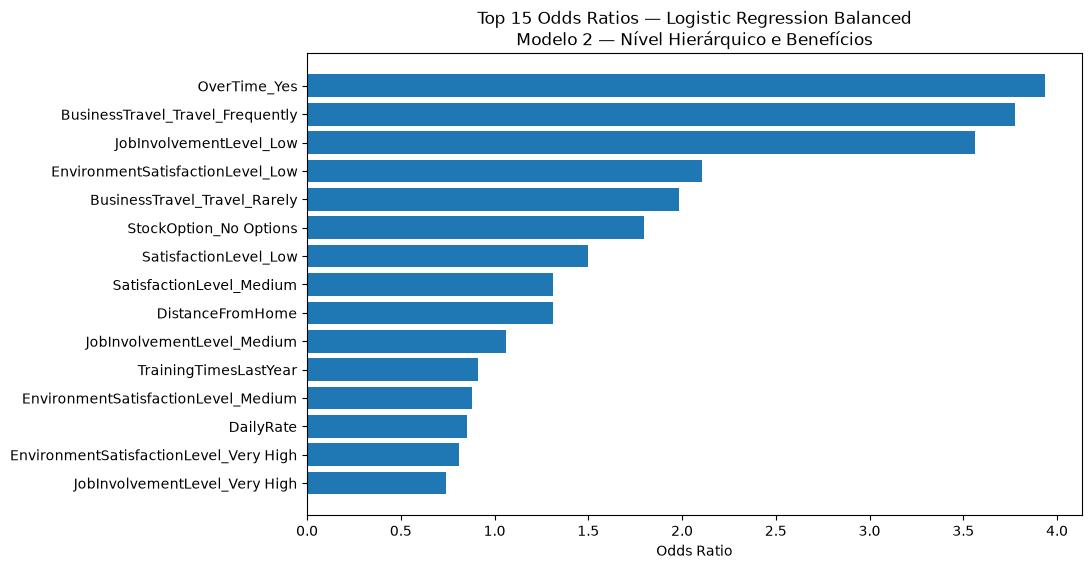

,Feature,Coefficient,Odds_Ratio
3,OverTime_Yes,1.370390,3.936886
11,BusinessTravel_Travel_Frequently,1.328446,3.775173
13,JobInvolvementLevel_Low,1.270545,3.562792
16,EnvironmentSatisfactionLevel_Low,0.745495,2.107485
12,BusinessTravel_Travel_Rarely,0.685256,1.984279
10,StockOption_No Options,0.585013,1.795014
19,SatisfactionLevel_Low,0.405159,1.499540
20,SatisfactionLevel_Medium,0.272104,1.312723
0,DistanceFromHome,0.270126,1.310130
14,JobInvolvementLevel_Medium,0.059910,1.061741


In [7]:
for _, row in top_5_best_lr.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    importance_df = interpretation_results_lr[variable_set_name][model_name].copy()
    
    top_importance = importance_df.head(15).sort_values(by="Odds_Ratio", ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_importance["Feature"], top_importance["Odds_Ratio"])
    plt.xlabel("Odds Ratio")
    plt.title(f"Top 15 Odds Ratios — {model_name}\n{variable_set_name}")
    plt.show()
    
    display(importance_df.head(20))

Background dataset has 1029 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1029 when initializing the masker.


SHAP — Logistic Regression | Modelo 8 — Integrado Multidimensional


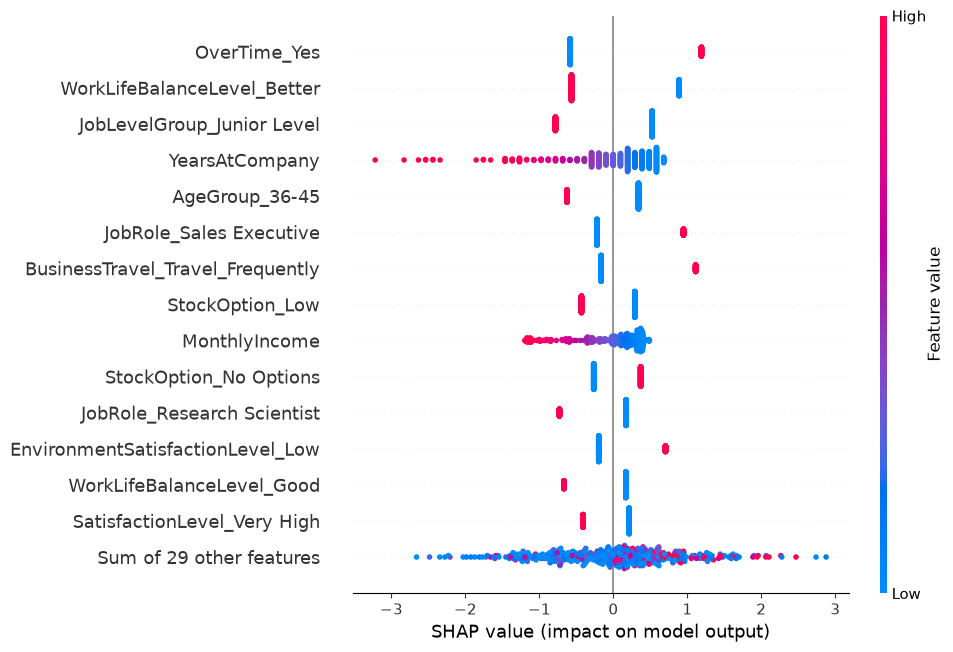

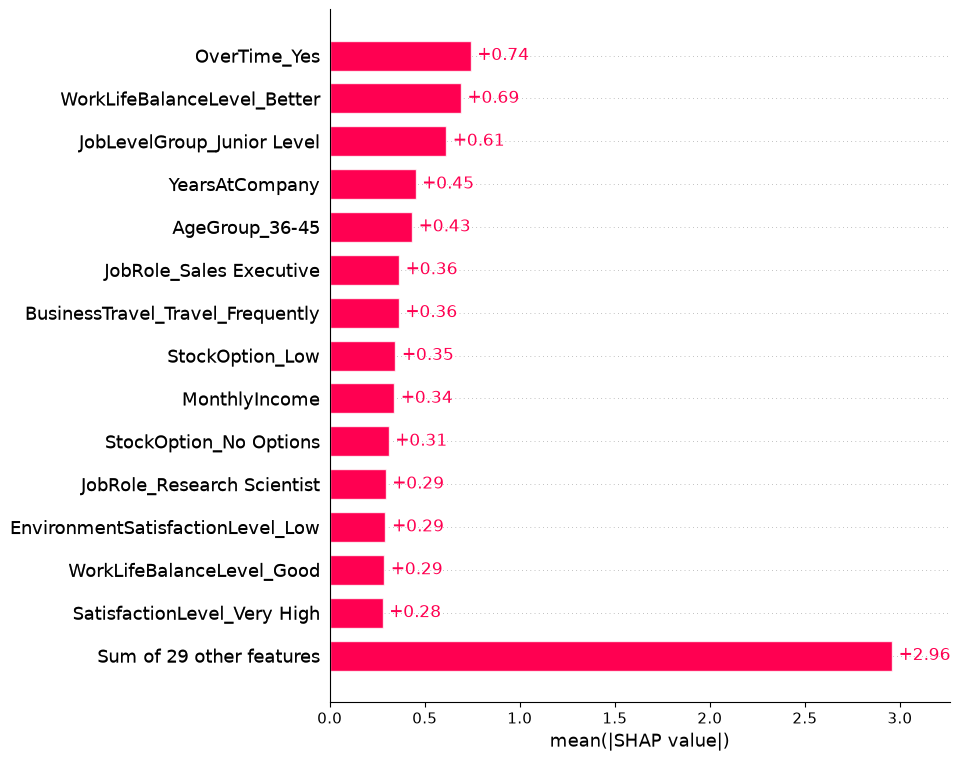

Background dataset has 1029 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1029 when initializing the masker.


SHAP — Logistic Regression | Modelo 2 — Nível Hierárquico e Benefícios


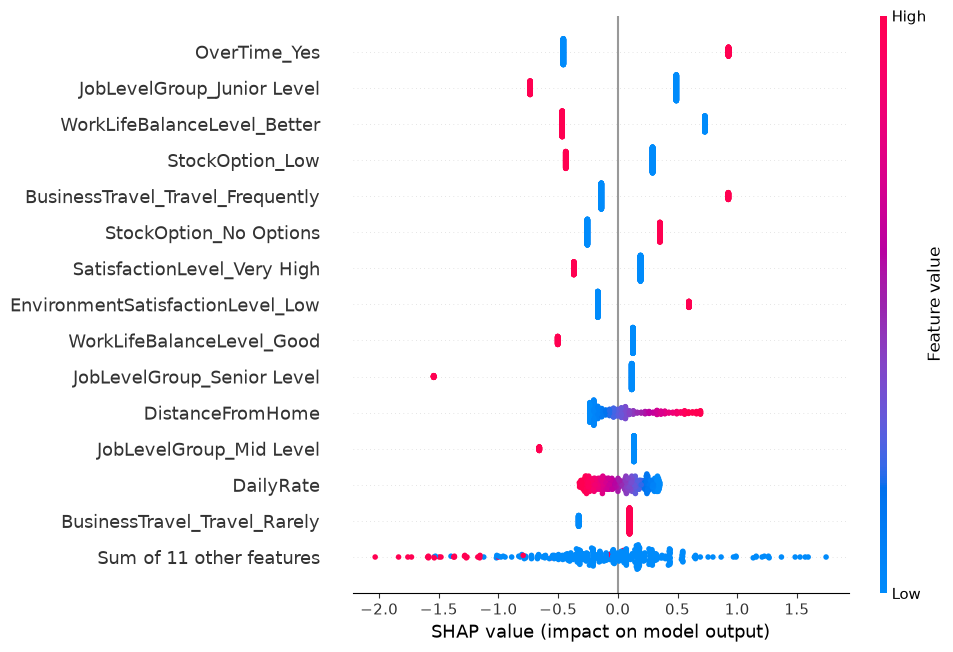

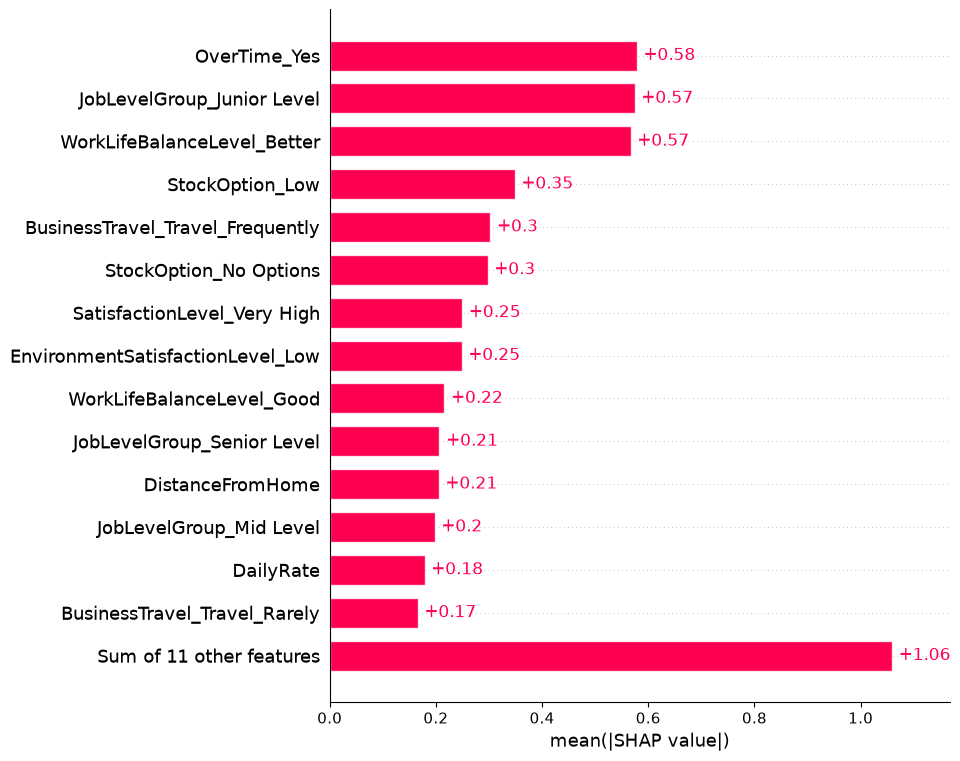

Background dataset has 1029 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1029 when initializing the masker.


SHAP — Logistic Regression Balanced | Modelo 8 — Integrado Multidimensional


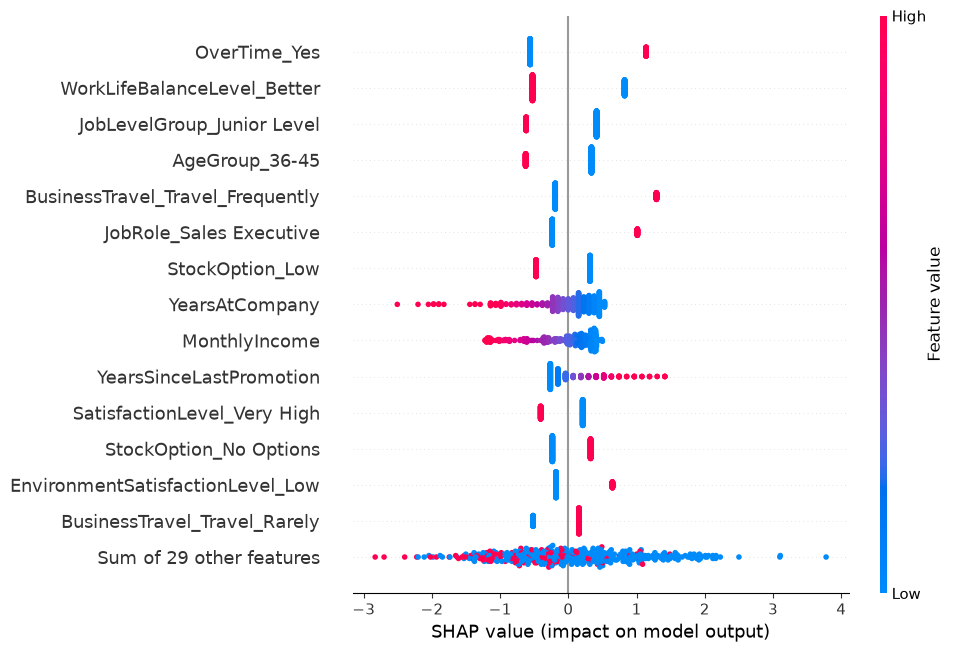

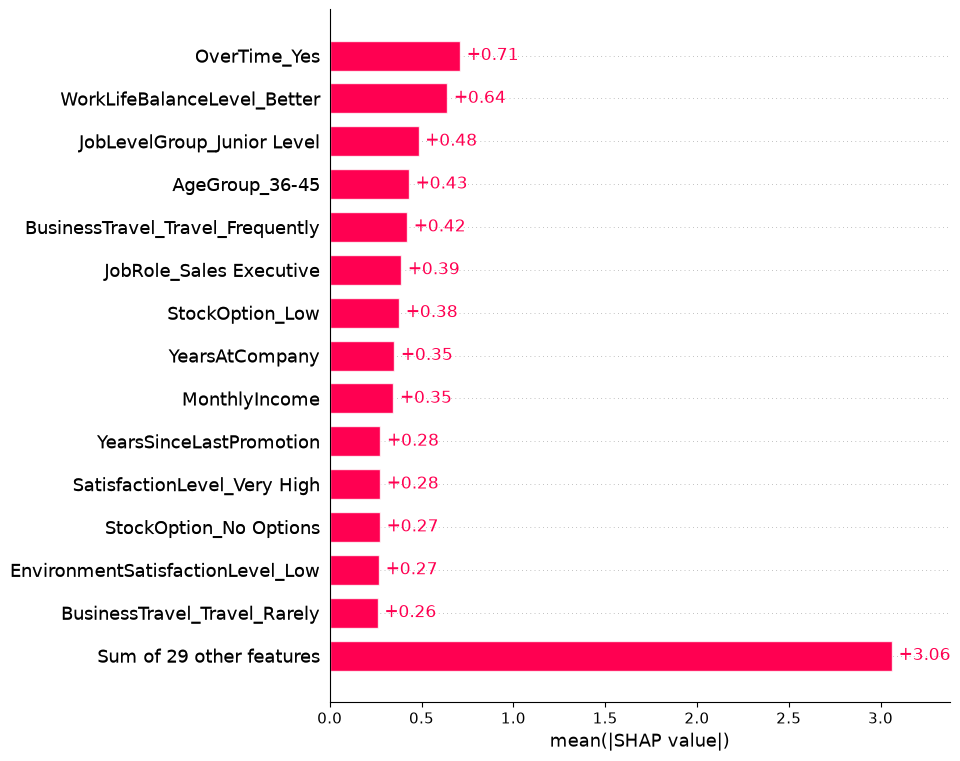

Background dataset has 1029 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1029 when initializing the masker.


SHAP — Logistic Regression Balanced | Modelo 3 — Faixa Salarial


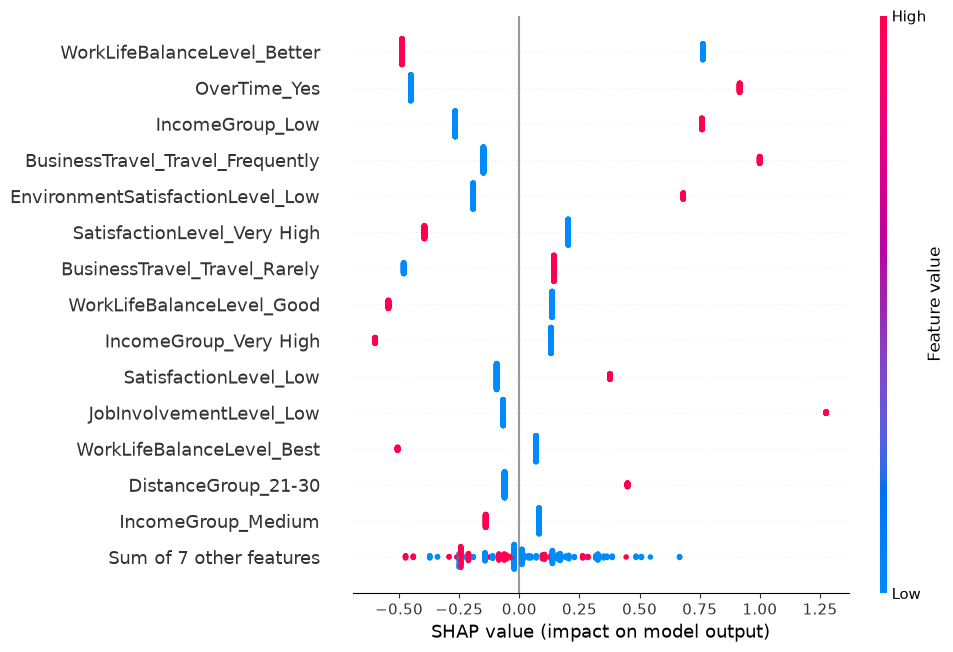

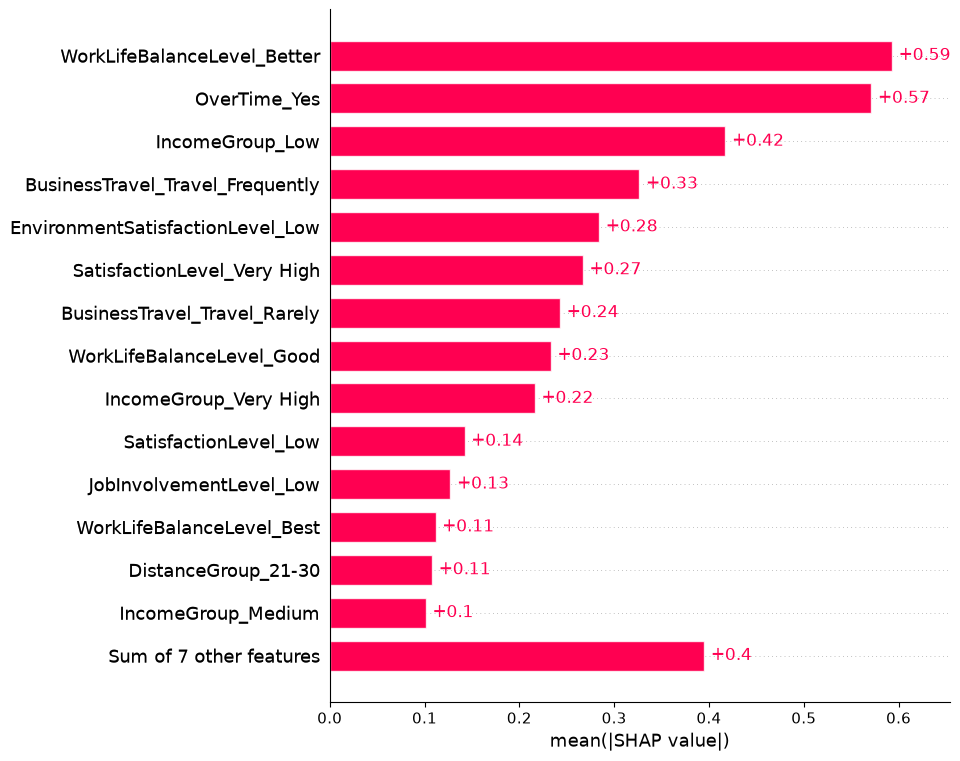

Background dataset has 1029 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1029 when initializing the masker.


SHAP — Logistic Regression Balanced | Modelo 2 — Nível Hierárquico e Benefícios


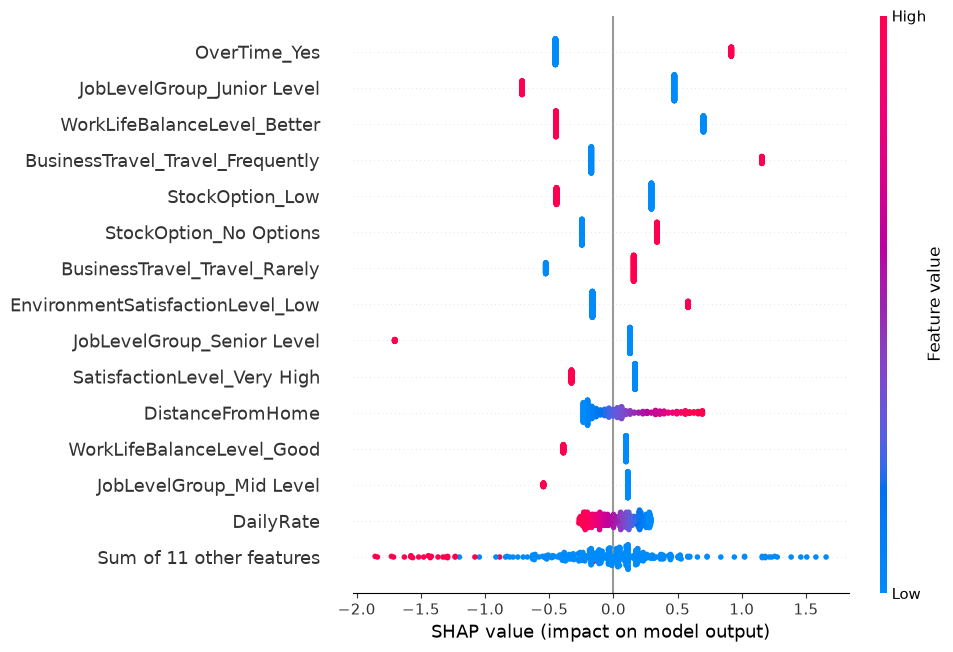

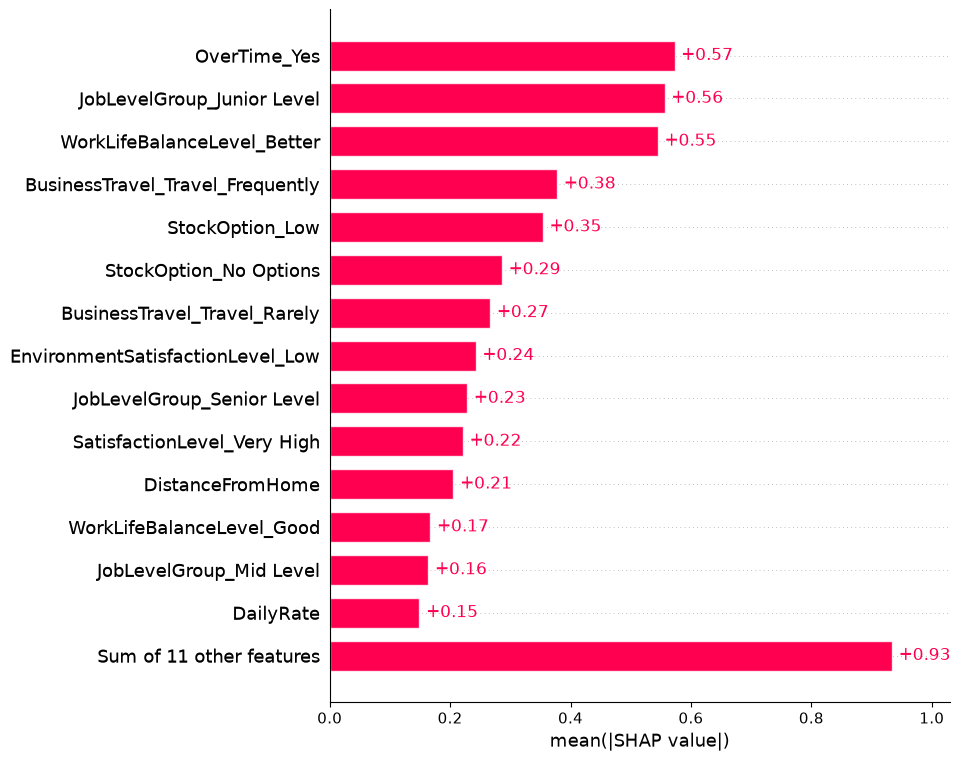

In [8]:
for _, row in top_5_best_lr.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    X_train_model = X_train.copy()
    X_test_model = X_test.copy()
    
    if len(numeric_vars) > 0:
        
        numeric_cols_existing = [
            col for col in numeric_vars
            if col in X_train_model.columns
        ]
        
        scaler = StandardScaler()
        
        X_train_model[numeric_cols_existing] = scaler.fit_transform(
            X_train_model[numeric_cols_existing]
        )
        
        X_test_model[numeric_cols_existing] = scaler.transform(
            X_test_model[numeric_cols_existing]
        )
    
    estimator = clone(logistic_estimators_dict[model_name]["estimator"])
    estimator.fit(X_train_model, y_train)
    
    explainer = shap.LinearExplainer(estimator, X_train_model)
    shap_values = explainer(X_test_model)
    
    print(f"SHAP — {model_name} | {variable_set_name}")
    
    shap.plots.beeswarm(shap_values, max_display=15)
    shap.plots.bar(shap_values, max_display=15)

# Validação Cruzada

In [9]:
cv_logistic = run_cross_validation_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict={
        "Logistic Regression": estimators_dict["Logistic Regression"],
        "Logistic Regression Balanced": estimators_dict["Logistic Regression Balanced"]
    },
    target="AttritionFlag"
)

cv_logistic.sort_values("F1_Mean", ascending=False)

,Variable_Set,Model,Accuracy_Mean,Accuracy_Std,Precision_Mean,Precision_Std,Recall_Mean,Recall_Std,F1_Mean,F1_Std,AUC_Mean,AUC_Std,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
29,Modelo 8 — Integrado Multidimensional,Logistic Regression Balanced,0.780,0.042,0.408,0.060,0.780,0.087,0.535,0.071,0.839,0.057,7,11,43
28,Modelo 8 — Integrado Multidimensional,Logistic Regression,0.869,0.021,0.667,0.109,0.384,0.091,0.483,0.094,0.844,0.052,7,11,43
17,Modelo 2 — Nível Hierárquico e Benefícios,Logistic Regression Balanced,0.750,0.028,0.363,0.038,0.725,0.085,0.483,0.048,0.814,0.048,3,8,25
11,Modelo 6 — Perfil Pessoal,Logistic Regression Balanced,0.740,0.029,0.354,0.033,0.730,0.040,0.476,0.036,0.795,0.049,0,9,24
21,Modelo 4 — Experiência Profissional,Logistic Regression Balanced,0.737,0.048,0.353,0.050,0.729,0.076,0.474,0.057,0.789,0.051,4,6,19
25,Modelo 6 — Perfil Pessoal e Condições de Trabalho,Logistic Regression Balanced,0.740,0.032,0.353,0.038,0.722,0.066,0.473,0.043,0.800,0.052,3,8,24
15,Modelo 1 — Função Profissional Misto,Logistic Regression Balanced,0.733,0.025,0.344,0.033,0.725,0.086,0.466,0.047,0.800,0.057,3,7,26
9,Modelo 5 — Estabilidade e Benefícios,Logistic Regression Balanced,0.739,0.034,0.350,0.041,0.700,0.062,0.465,0.038,0.797,0.048,0,9,24
3,Modelo 2 — Nível Hierárquico,Logistic Regression Balanced,0.737,0.041,0.348,0.050,0.704,0.072,0.465,0.057,0.787,0.053,0,8,22
7,Modelo 4 — Trajetória Organizacional,Logistic Regression Balanced,0.732,0.052,0.347,0.069,0.708,0.081,0.464,0.076,0.790,0.049,0,8,22
